# Python _in_ Electrical Engineering
## Electrical Circuits Simulations with PySpice
1. Install PySpice and Ngspice and/or verify your setup.
2. Simulate the step response of an RC circuit (R = 1 kΩ, C = 1 μF, input 0→5 V) and an RL circuit (R = 10 Ω, L = 10 mH, input 0→10 V). Plot input voltage voltages at L, C components _in_ these circuits. 
3. Simulate a series RLC circuit (R = 50 Ω, L = 100 mH, C = 10 μF) with a sinusoidal source (e.g., 50 Hz), measure voltage and current, and compute active power (P), reactive power (Q), and apparent power (S), commenting on phase shift and whether the circuit is inductive or capacitive.
4. Extend the RLC circuit analysis by introducing power factor correction: add a compensating capacitor (or inductor) to reduce reactive power, re-simulate the circuit, and compare P, Q, S, and power factor before and after compensation, explaining how compensation improves energy efficiency.
5. Prepare a report including circuit schematics, simulation plots, calculated values, and a short discussion of your results and conclusions.

Part 1:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import PySpice.Logging.Logging as Logging
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *
from PySpice.Spice.NgSpice.Shared import NgSpiceShared
logger = Logging.setup_logging(logging_level=logging.DEBUG)

#print(logger)
# check the instalation of pyspice

In [3]:
# original_send_char = NgSpiceShared._send_char

# def patched_send_char(self, message, message_id):
#     msg_str = message.decode('utf-8', errors='ignore') if isinstance(message, bytes) else str(message)
    
#     if "Using SPARSE" in msg_str or "compatibility mode" in msg_str:
#         return 0 
        
#     return original_send_char(self, message, message_id)

# # REPLACE THE STDERR DATA
# NgSpiceShared._send_char = patched_send_char

Part 2:


2026-04-07 19:32:57,907 - PySpice.Spice.NgSpice.Simulation.NgSpiceSharedCircuitSimulator - Simulation.DEBUG - desk
.title RC Step Response
Vinput _in_ 0 DC 0V PULSE(0V 5V 0s 1us 1us 5ms 10ms)
R1 _in_ out 1kOhm
C1 out 0 1uF
.options TEMP = 25C
.options TNOM = 25C
.tran 10us 15ms 0s
.end

2026-04-07 19:32:57,919 - PySpice.Spice.NgSpice.Simulation.NgSpiceSharedCircuitSimulator - Simulation.DEBUG - ['tran1', 'const']
2026-04-07 19:32:57,921 - PySpice.Spice.NgSpice.Simulation.NgSpiceSharedCircuitSimulator - Simulation.DEBUG - desk
.title RL Step Response
Vinput _in_ 0 DC 0V PULSE(0V 10V 0s 1us 1us 5ms 10ms)
R1 _in_ out 10Ohm
L1 out 0 10mH
.options TEMP = 25C
.options TNOM = 25C
.tran 10us 15ms 0s
.end

2026-04-07 19:32:57,927 - PySpice.Spice.NgSpice.Simulation.NgSpiceSharedCircuitSimulator - Simulation.DEBUG - ['tran1', 'const']


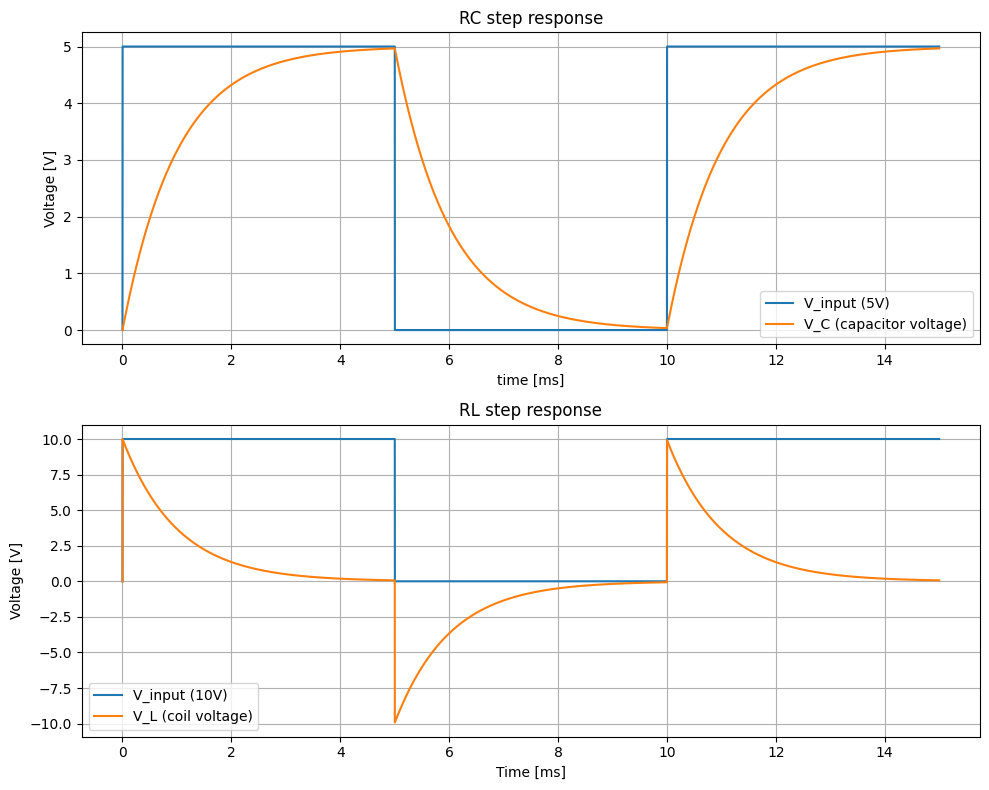

In [4]:
# --- RC circuit ---
circuit_rc = Circuit('RC Step Response')
# (0 to 5V, start 0s, 10us, time 5ms)
circuit_rc.PulseVoltageSource('input', '_in_', circuit_rc.gnd,
                              initial_value=0@u_V, pulsed_value=5@u_V,
                              delay_time=0@u_s, rise_time=1@u_us, fall_time=1@u_us,
                              pulse_width=5@u_ms, period=10@u_ms)
circuit_rc.R(1, '_in_', 'out', 1@u_kOhm)
circuit_rc.C(1, 'out', circuit_rc.gnd, 1@u_uF)

simulator_rc = circuit_rc.simulator(temperature=25, nominal_temperature=25, simulator='ngspice-shared')
analysis_rc = simulator_rc.transient(step_time=10@u_us, end_time=15@u_ms)

# --- RL circuit ---
circuit_rl = Circuit('RL Step Response')
circuit_rl.PulseVoltageSource('input', '_in_', circuit_rl.gnd,
                              initial_value=0@u_V, pulsed_value=10@u_V,
                              delay_time=0@u_s, rise_time=1@u_us, fall_time=1@u_us,
                              pulse_width=5@u_ms, period=10@u_ms)
circuit_rl.R(1, '_in_', 'out', 10@u_Ohm)
circuit_rl.L(1, 'out', circuit_rl.gnd, 10@u_mH)

simulator_rl = circuit_rl.simulator(temperature=25, nominal_temperature=25, simulator='ngspice-shared')
analysis_rl = simulator_rl.transient(step_time=10@u_us, end_time=15@u_ms)

# --- plots ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# RC circuit plot
time_rc = np.array(analysis_rc.time) * 1000 # miliseconds
ax1.plot(time_rc, np.array(analysis_rc['_in_']), label='V_input (5V)')
ax1.plot(time_rc, np.array(analysis_rc['out']), label='V_C (capacitor voltage)')
ax1.set_title('RC step response')
ax1.set_xlabel('time [ms]')
ax1.set_ylabel('Voltage [V]')
ax1.grid()
ax1.legend()

# RL circuit plot 
time_rl = np.array(analysis_rl.time) * 1000
ax2.plot(time_rl, np.array(analysis_rl['_in_']), label='V_input (10V)')
ax2.plot(time_rl, np.array(analysis_rl['out']), label='V_L (coil voltage)')
ax2.set_title('RL step response')
ax2.set_xlabel('Time [ms]')
ax2.set_ylabel('Voltage [V]')
ax2.grid()
ax2.legend()

plt.tight_layout()
plt.show()

Part 3:

In [5]:
circuit_rlc = Circuit('Series RLC')

# Sinusoidal source 50 Hz, amplitude 10V
circuit_rlc.SinusoidalVoltageSource('source', 'in', circuit_rlc.gnd, amplitude=10@u_V, frequency=50@u_Hz)
circuit_rlc.R(1, 'in', 'n1', 50@u_Ohm)
circuit_rlc.L(1, 'n1', 'n2', 100@u_mH)
circuit_rlc.C(1, 'n2', circuit_rlc.gnd, 10@u_uF)

# Simulation of 4 full periods (80 ms for 50 Hz)
simulator_rlc = circuit_rlc.simulator(temperature=25, nominal_temperature=25)
analysis_rlc = simulator_rlc.transient(step_time=50@u_us, end_time=80@u_ms)

# Data extraction (we take only the last 2 periods to skip transients)
time = np.array(analysis_rlc.time)
v_in = np.array(analysis_rlc['in'])

# Circuit current = voltage across resistor divided by its resistance
i_in = (np.array(analysis_rlc['in']) - np.array(analysis_rlc['n1'])) / 50.0 

# Limit data to steady-state (from 40 ms to 80 ms)
mask = time >= 0.04
time_ss = time[mask]
v_ss = v_in[mask]
i_ss = i_in[mask]

# --- delete (DC OFFSET) ---
v_ss = v_ss - np.mean(v_ss)
i_ss = i_ss - np.mean(i_ss)
# ----------------------------------------------

# --- Power calculations ---
T = time_ss[-1] - time_ss[0]
V_rms = np.sqrt(np.trapz(v_ss**2, time_ss) / T)
I_rms = np.sqrt(np.trapz(i_ss**2, time_ss) / T)

S = V_rms * I_rms                      # Apparent power [VA]
P = np.trapz(v_ss * i_ss, time_ss) / T # Active power [W]

#floating point protection

Q = np.sqrt(max(S**2 - P**2, 0))       # Reactive power [var]

PF = P / S                             # Power Factor
phase_shift = np.arccos(PF) * (180/np.pi) # Phase shift in degrees

print(f"RLC circuit before compensation:")
print(f"V_rms = {V_rms:.2f} V, I_rms = {I_rms:.4f} A")
print(f"P (Active) = {P:.4f} W")
print(f"S (Apparent) = {S:.4f} VA")
print(f"Q (Reactive) = {Q:.4f} var")
print(f"Power Factor (PF) = {PF:.4f}")
print(f"Phase shift = {phase_shift:.2f} degrees")

2026-04-07 19:32:58,271 - PySpice.Spice.NgSpice.Simulation.NgSpiceSharedCircuitSimulator - Simulation.DEBUG - desk
.title Series RLC
Vsource in 0 DC 0V AC 1V SIN(0V 10V 50Hz 0s 0Hz)
R1 in n1 50Ohm
L1 n1 n2 100mH
C1 n2 0 10uF
.options TEMP = 25C
.options TNOM = 25C
.tran 50us 80ms 0s
.end

2026-04-07 19:32:58,279 - PySpice.Spice.NgSpice.Simulation.NgSpiceSharedCircuitSimulator - Simulation.DEBUG - ['tran1', 'const']
RLC circuit before compensation:
V_rms = 7.07 V, I_rms = 0.0243 A
P (Active) = 0.0295 W
S (Apparent) = 0.1717 VA
Q (Reactive) = 0.1691 var
Power Factor (PF) = 0.1718
Phase shift = 80.11 degrees


Part 4:


In [6]:
circuit_pfc = Circuit('Series RLC with PFC')
circuit_pfc.SinusoidalVoltageSource('source', 'in', circuit_pfc.gnd, amplitude=10@u_V, frequency=50@u_Hz)

# Original RLC branch
circuit_pfc.R(1, 'in', 'n1', 50@u_Ohm)
circuit_pfc.L(1, 'n1', 'n2', 100@u_mH)
circuit_pfc.C(1, 'n2', circuit_pfc.gnd, 10@u_uF)

# NEW ELEMENT: Compensation inductor in parallel with the source
circuit_pfc.L('comp', 'in', 'n_comp', 0.96@u_H)
circuit_pfc.R('comp_r', 'n_comp', circuit_pfc.gnd, 1@u_mOhm)

# Simulation
simulator_pfc = circuit_pfc.simulator(temperature=25, nominal_temperature=25)
analysis_pfc = simulator_pfc.transient(step_time=50@u_us, end_time=80@u_ms)

time_pfc = np.array(analysis_pfc.time)
v_in_pfc = np.array(analysis_pfc['in'])

# Total current = sum of current in the RLC branch and compensation inductor current
i_total_pfc = np.array(analysis_pfc.branches['vsource']) * -1  # Sign convention

# --- Steady state after 40ms  ---
mask_pfc = time_pfc >= 0.04
time_ss_pfc = time_pfc[mask_pfc]
v_ss_pfc = v_in_pfc[mask_pfc]
i_ss_pfc = i_total_pfc[mask_pfc]

# --- Delete (DC OFFSET) ---
v_ss_pfc = v_ss_pfc - np.mean(v_ss_pfc)
i_ss_pfc = i_ss_pfc - np.mean(i_ss_pfc)
# -----------------------------------------------

# Calculations
T_pfc = time_ss_pfc[-1] - time_ss_pfc[0]
V_rms_pfc = np.sqrt(np.trapz(v_ss_pfc**2, time_ss_pfc) / T_pfc)
I_rms_pfc = np.sqrt(np.trapz(i_ss_pfc**2, time_ss_pfc) / T_pfc)

S_pfc = V_rms_pfc * I_rms_pfc
P_pfc = np.trapz(v_ss_pfc * i_ss_pfc, time_ss_pfc) / T_pfc

# Protection against floating-point errors
Q_pfc = np.sqrt(max(S_pfc**2 - P_pfc**2, 0)) 
PF_pfc = P_pfc / S_pfc
phase_shift_pfc = np.arccos(PF_pfc) * (180/np.pi) # Phase shift in degrees

print(f"Circuit after PFC compensation (L_comp = 0.96 H):")
print(f"V_rms = {V_rms_pfc:.2f} V, I_rms = {I_rms_pfc:.4f} A")
print(f"P (Active) = {P_pfc:.4f} W")
print(f"S (Apparent) = {S_pfc:.4f} VA")
print(f"Q (Reactive) = {Q_pfc:.4f} var")
print(f"Power Factor (PF) = {PF_pfc:.4f}")
print(f"Phase shift = {phase_shift_pfc:.2f} degrees")

2026-04-07 19:32:58,294 - PySpice.Spice.NgSpice.Simulation.NgSpiceSharedCircuitSimulator - Simulation.DEBUG - desk
.title Series RLC with PFC
Vsource in 0 DC 0V AC 1V SIN(0V 10V 50Hz 0s 0Hz)
R1 in n1 50Ohm
L1 n1 n2 100mH
C1 n2 0 10uF
Lcomp in n_comp 0.96H
Rcomp_r n_comp 0 1mOhm
.options TEMP = 25C
.options TNOM = 25C
.tran 50us 80ms 0s
.end

2026-04-07 19:32:58,304 - PySpice.Spice.NgSpice.Simulation.NgSpiceSharedCircuitSimulator - Simulation.DEBUG - ['tran1', 'const']
Circuit after PFC compensation (L_comp = 0.96 H):
V_rms = 7.07 V, I_rms = 0.0042 A
P (Active) = 0.0295 W
S (Apparent) = 0.0297 VA
Q (Reactive) = 0.0034 var
Power Factor (PF) = 0.9936
Phase shift = 6.50 degrees


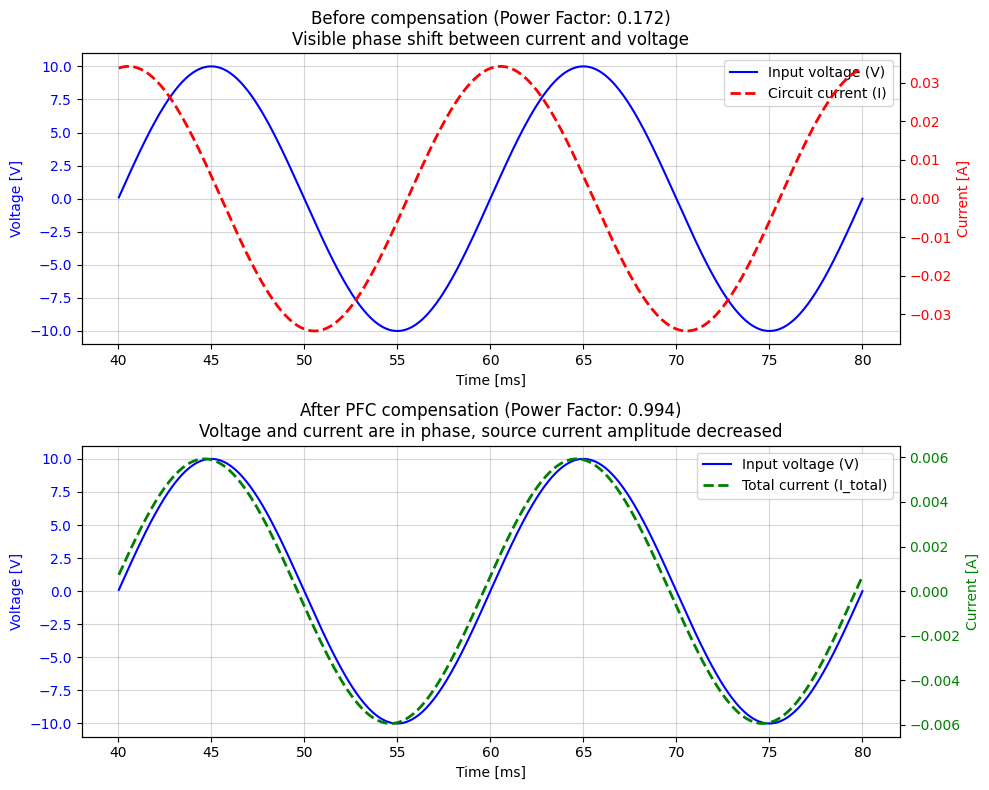

In [7]:
import matplotlib.pyplot as plt

# ==========================================
# --- Plots for parts 3 and 4 (RLC and PFC) ---
# ==========================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# --- Plot 1: Before compensation ---
# Convert time to milliseconds for better readability
time_ms = time_ss * 1000 

# Main axis (left) - Voltage
ax1.plot(time_ms, v_ss, color='blue', label='Input voltage (V)')
ax1.set_xlabel('Time [ms]')
ax1.set_ylabel('Voltage [V]', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.5)

# Secondary axis (right) - Current
ax1_i = ax1.twinx()
ax1_i.plot(time_ms, i_ss, color='red', linestyle='--', linewidth=2, label='Circuit current (I)')
ax1_i.set_ylabel('Current [A]', color='red')
ax1_i.tick_params(axis='y', labelcolor='red')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines1_i, labels1_i = ax1_i.get_legend_handles_labels()
ax1.legend(lines1 + lines1_i, labels1 + labels1_i, loc='upper right')
ax1.set_title(f'Before compensation (Power Factor: {PF:.3f})\nVisible phase shift between current and voltage')


# --- Plot 2: After PFC compensation ---
time_pfc_ms = time_ss_pfc * 1000

# Main axis (left) - Voltage
ax2.plot(time_pfc_ms, v_ss_pfc, color='blue', label='Input voltage (V)')
ax2.set_xlabel('Time [ms]')
ax2.set_ylabel('Voltage [V]', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.grid(True, alpha=0.5)

# Secondary axis (right) - Total current
ax2_i = ax2.twinx()
ax2_i.plot(time_pfc_ms, i_ss_pfc, color='green', linestyle='--', linewidth=2, label='Total current (I_total)')
ax2_i.set_ylabel('Current [A]', color='green')
ax2_i.tick_params(axis='y', labelcolor='green')

# Combine legends from both axes
lines2, labels2 = ax2.get_legend_handles_labels()
lines2_i, labels2_i = ax2_i.get_legend_handles_labels()
ax2.legend(lines2 + lines2_i, labels2 + labels2_i, loc='upper right')
ax2.set_title(f'After PFC compensation (Power Factor: {PF_pfc:.3f})\nVoltage and current are in phase, source current amplitude decreased')

plt.tight_layout()
plt.show()